In [1]:
# Load both datasets
biomarkers <- read.csv("/kaggle/input/datasets/yousufaayon/pmim202-cognitive-decline/pmim202_biomarkers_dataset.csv")
imaging    <- read.csv("/kaggle/input/datasets/yousufaayon/pmim202-cognitive-decline/pmim202_imaging_genetic_dataset.csv")

# Biomarkers dataset
cat(" Biomarkers Dataset \n")
cat("Shape:", nrow(biomarkers), "rows x", ncol(biomarkers), "cols\n")
cat("Columns:\n")
print(names(biomarkers))
cat("\nFirst 3 rows:\n")
print(head(biomarkers, 3))

# Imaging/genetic dataset
cat("\n=== Imaging & Genetic Dataset ===\n")
cat("Shape:", nrow(imaging), "rows x", ncol(imaging), "cols\n")
cat("Columns:\n")
print(names(imaging))
cat("\nFirst 3 rows:\n")
print(head(imaging, 3))

 Biomarkers Dataset 
Shape: 240 rows x 10 cols
Columns:
 [1] "ParticipantID"              "BMI_kg_m2"                 
 [3] "SystolicBP_mmHg"            "PhysicalActivity_METS_week"
 [5] "SleepQuality_PSQI"          "Plasma_pTau217_pg_mL"      
 [7] "Plasma_NfL_pg_mL"           "HbA1c_mmol_mol"            
 [9] "FollowUpMoCA_12m"           "MoCA_Change_12m"           

First 3 rows:
  ParticipantID BMI_kg_m2 SystolicBP_mmHg PhysicalActivity_METS_week
1       PMIM001      25.0           127.1                       1821
2       PMIM002      23.6           132.0                       1028
3       PMIM003      25.4           138.3                        544
  SleepQuality_PSQI Plasma_pTau217_pg_mL Plasma_NfL_pg_mL HbA1c_mmol_mol
1               8.0                1.257            13.02           37.8
2               5.6                1.851            11.83           39.0
3               6.1                1.506            12.53           36.6
  FollowUpMoCA_12m MoCA_Change_12m
1          

In [2]:
# Merge on ParticipantID
df <- merge(biomarkers, imaging, by = "ParticipantID")

cat("=== Merged Dataset ===\n")
cat("Shape:", nrow(df), "rows x", ncol(df), "cols\n")

# Convert categorical variables
df$Sex          <- as.factor(df$Sex)
df$APOE4_Carrier <- as.factor(df$APOE4_Carrier)
df$Diagnosis    <- factor(df$Diagnosis, levels = c("CN", "MCI", "AD"))

# Check for missing values
cat("\n=== Missing Values ===\n")
print(colSums(is.na(df)))

# Summary by diagnostic group
cat("\n=== Group Counts ===\n")
print(table(df$Diagnosis))

cat("\n=== Key Variable Summary by Diagnosis ===\n")
for (grp in c("CN", "MCI", "AD")) {
  sub <- df[df$Diagnosis == grp, ]
  cat(sprintf("\n%s (n=%d):\n", grp, nrow(sub)))
  cat(sprintf("  Age:               mean=%.1f, sd=%.1f\n",
              mean(sub$Age), sd(sub$Age)))
  cat(sprintf("  MoCA Change 12m:   mean=%.2f, sd=%.2f\n",
              mean(sub$MoCA_Change_12m), sd(sub$MoCA_Change_12m)))
  cat(sprintf("  Physical Activity: mean=%.1f, sd=%.1f\n",
              mean(sub$PhysicalActivity_METS_week), sd(sub$PhysicalActivity_METS_week)))
  cat(sprintf("  Sleep Quality:     mean=%.1f, sd=%.1f\n",
              mean(sub$SleepQuality_PSQI), sd(sub$SleepQuality_PSQI)))
  cat(sprintf("  BMI:               mean=%.1f, sd=%.1f\n",
              mean(sub$BMI_kg_m2), sd(sub$BMI_kg_m2)))
}

=== Merged Dataset ===
Shape: 240 rows x 22 cols

=== Missing Values ===
             ParticipantID                  BMI_kg_m2 
                         0                          0 
           SystolicBP_mmHg PhysicalActivity_METS_week 
                         0                          0 
         SleepQuality_PSQI       Plasma_pTau217_pg_mL 
                         0                          0 
          Plasma_NfL_pg_mL             HbA1c_mmol_mol 
                         0                          0 
          FollowUpMoCA_12m            MoCA_Change_12m 
                         0                          0 
                       Age                        Sex 
                         0                          0 
            EducationYears              APOE4_Carrier 
                         0                          0 
                 Diagnosis       HippocampalVolume_mL 
                         0                          0 
      CorticalThickness_mm     FunctionalConnec

=== Pearson Correlations with MoCA Change at 12 Months ===
Predictor                                r          95% CI       p
---------------------------------------------------------------------- 
Physical Activity (METs/week)        0.303  [0.183, 0.413]   0.0000**
Sleep Quality (PSQI)                -0.178  [-0.298, -0.053]   0.0057**
BMI (kg/m²)                        -0.302  [-0.413, -0.182]   0.0000**
Systolic BP (mmHg)                  -0.175  [-0.295, -0.050]   0.0064**
HbA1c (mmol/mol)                    -0.168  [-0.289, -0.043]   0.0090**


`geom_smooth()` using formula = 'y ~ x'


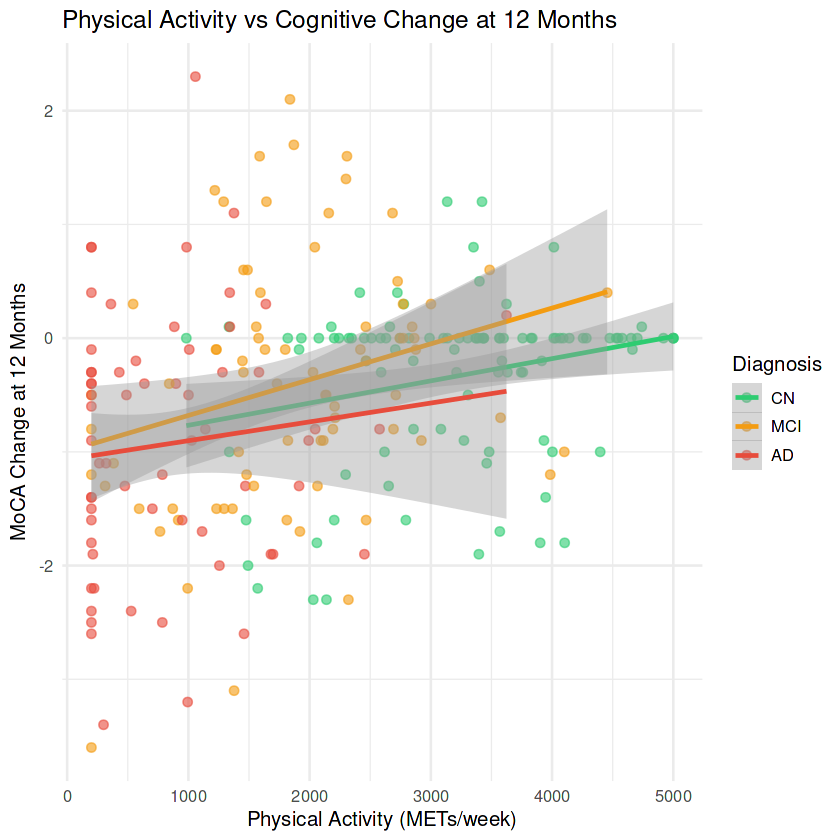

In [3]:
library(ggplot2)

# Five lifestyle predictors vs MoCA change
predictors <- list(
  "Physical Activity (METs/week)" = "PhysicalActivity_METS_week",
  "Sleep Quality (PSQI)"          = "SleepQuality_PSQI",
  "BMI (kg/m²)"                   = "BMI_kg_m2",
  "Systolic BP (mmHg)"            = "SystolicBP_mmHg",
  "HbA1c (mmol/mol)"              = "HbA1c_mmol_mol"
)

cat("=== Pearson Correlations with MoCA Change at 12 Months ===\n")
cat(sprintf("%-35s %6s %15s %7s\n", "Predictor", "r", "95% CI", "p"))
cat(strrep("-", 70), "\n")

cor_results <- list()
for (label in names(predictors)) {
  col  <- predictors[[label]]
  test <- cor.test(df[[col]], df$MoCA_Change_12m, method = "pearson")
  ci   <- test$conf.int
  cat(sprintf("%-35s %6.3f  [%5.3f, %5.3f]  %7.4f%s\n",
              label, test$estimate, ci[1], ci[2], test$p.value,
              ifelse(test$p.value < 0.01, "**",
              ifelse(test$p.value < 0.05, "*", ""))))
  cor_results[[col]] <- test
}

# Scatter plot — Physical Activity vs MoCA Change (coloured by diagnosis)
ggplot(df, aes(x = PhysicalActivity_METS_week,
               y = MoCA_Change_12m,
               colour = Diagnosis)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_smooth(method = "lm", se = TRUE, aes(group = Diagnosis)) +
  scale_colour_manual(values = c("CN" = "#2ecc71",
                                 "MCI" = "#f39c12",
                                 "AD"  = "#e74c3c")) +
  labs(title = "Physical Activity vs Cognitive Change at 12 Months",
       x     = "Physical Activity (METs/week)",
       y     = "MoCA Change at 12 Months",
       colour = "Diagnosis") +
  theme_minimal(base_size = 12)

=== One-Way ANOVA: MoCA Change by Diagnosis ===
             Df Sum Sq Mean Sq F value   Pr(>F)    
Diagnosis     2  15.25   7.627   8.226 0.000352 ***
Residuals   237 219.75   0.927                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

=== Tukey Post-Hoc Tests ===
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = MoCA_Change_12m ~ Diagnosis, data = df)

$Diagnosis
              diff        lwr        upr     p adj
MCI-CN -0.07260292 -0.4174661  0.2722602 0.8730353
AD-CN  -0.59985856 -0.9644602 -0.2352569 0.0003964
AD-MCI -0.52725564 -0.9142084 -0.1403028 0.0042451



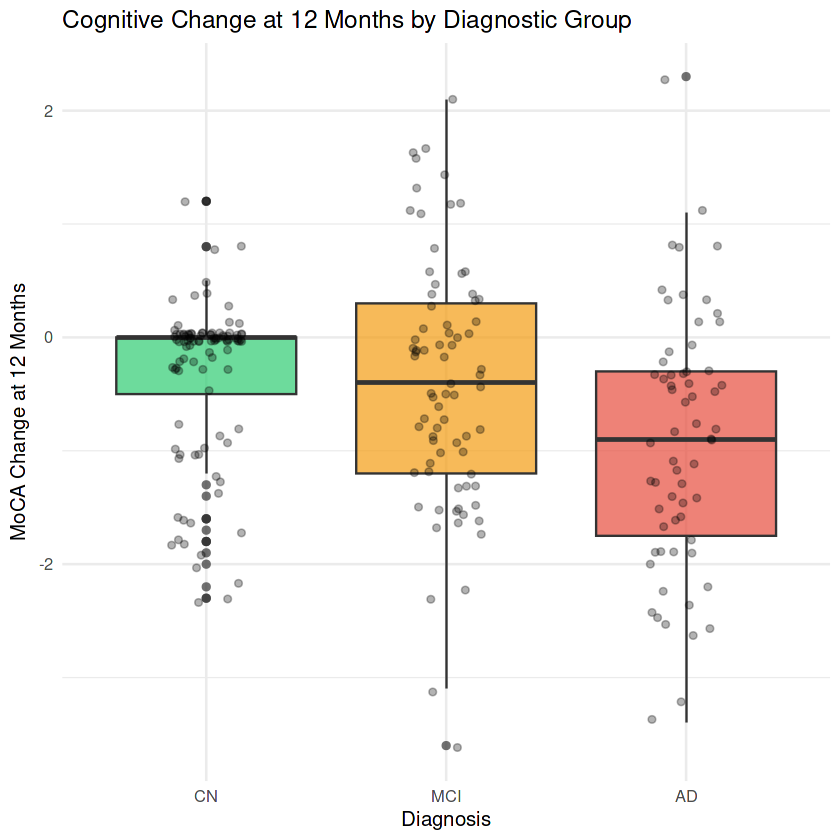

In [4]:
# One-way ANOVA: MoCA Change by Diagnosis
anova_model <- aov(MoCA_Change_12m ~ Diagnosis, data = df)
anova_summary <- summary(anova_model)

cat("=== One-Way ANOVA: MoCA Change by Diagnosis ===\n")
print(anova_summary)

# Tukey post-hoc tests
cat("\n=== Tukey Post-Hoc Tests ===\n")
tukey <- TukeyHSD(anova_model)
print(tukey)

# Boxplot: MoCA Change by Diagnosis
ggplot(df, aes(x = Diagnosis, y = MoCA_Change_12m, fill = Diagnosis)) +
  geom_boxplot(alpha = 0.7, outlier.shape = 16, outlier.size = 2) +
  geom_jitter(width = 0.15, alpha = 0.3, size = 1.5) +
  scale_fill_manual(values = c("CN"  = "#2ecc71",
                                "MCI" = "#f39c12",
                                "AD"  = "#e74c3c")) +
  labs(title = "Cognitive Change at 12 Months by Diagnostic Group",
       x     = "Diagnosis",
       y     = "MoCA Change at 12 Months") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

Loading required package: carData



=== Multiple Linear Regression Summary ===

Call:
lm(formula = MoCA_Change_12m ~ Age + Sex + EducationYears + CognitiveScore_MoCA + 
    PhysicalActivity_METS_week + BMI_kg_m2 + SleepQuality_PSQI + 
    SystolicBP_mmHg + HbA1c_mmol_mol + APOE4_Carrier + Diagnosis, 
    data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.76981 -0.62508  0.09729  0.54237  3.01495 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)
(Intercept)                -2.6392444  3.3865464  -0.779    0.437
Age                         0.0760847  0.1412481   0.539    0.591
SexMale                     0.0431016  0.2520235   0.171    0.864
EducationYears              0.0248242  0.0251274   0.988    0.324
CognitiveScore_MoCA         0.0307296  0.0502144   0.612    0.541
PhysicalActivity_METS_week  0.0001377  0.0001244   1.107    0.269
BMI_kg_m2                  -0.2118395  0.3222610  -0.657    0.512
SleepQuality_PSQI          -0.0141069  0.0394989  -0.357    0.721
Systol

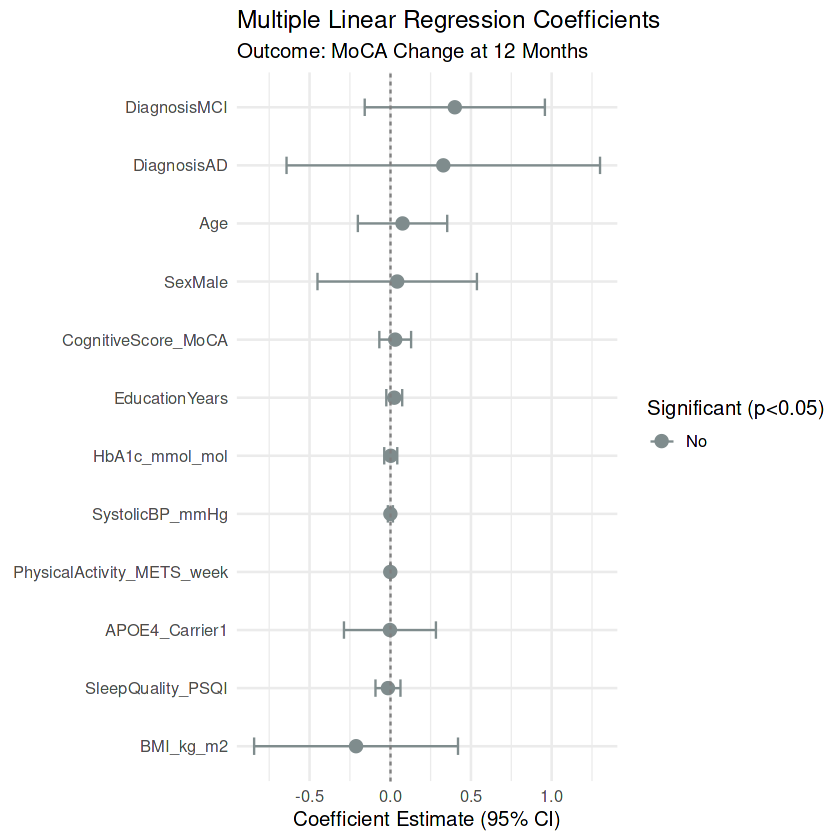

In [5]:
library(car)

# Full regression model
model <- lm(MoCA_Change_12m ~ Age + Sex + EducationYears +
              CognitiveScore_MoCA + PhysicalActivity_METS_week +
              BMI_kg_m2 + SleepQuality_PSQI + SystolicBP_mmHg +
              HbA1c_mmol_mol + APOE4_Carrier + Diagnosis,
            data = df)

cat("=== Multiple Linear Regression Summary ===\n")
print(summary(model))

cat("\n=== Variance Inflation Factors (VIF) ===\n")
print(vif(model))

# Coefficient plot
coef_df <- as.data.frame(summary(model)$coefficients)
coef_df$Variable <- rownames(coef_df)
coef_df <- coef_df[coef_df$Variable != "(Intercept)", ]
coef_df$CI_lower <- coef_df$Estimate - 1.96 * coef_df$`Std. Error`
coef_df$CI_upper <- coef_df$Estimate + 1.96 * coef_df$`Std. Error`
coef_df$Significant <- ifelse(coef_df$`Pr(>|t|)` < 0.05, "Yes", "No")

ggplot(coef_df, aes(x = Estimate, y = reorder(Variable, Estimate),
                    colour = Significant)) +
  geom_point(size = 3) +
  geom_errorbarh(aes(xmin = CI_lower, xmax = CI_upper), height = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "gray50") +
  scale_colour_manual(values = c("Yes" = "#e74c3c", "No" = "#7f8c8d")) +
  labs(title = "Multiple Linear Regression Coefficients",
       subtitle = "Outcome: MoCA Change at 12 Months",
       x = "Coefficient Estimate (95% CI)",
       y = NULL,
       colour = "Significant (p<0.05)") +
  theme_minimal(base_size = 12)

=== Refined Model Summary (Age & BMI removed) ===

Call:
lm(formula = MoCA_Change_12m ~ Sex + EducationYears + CognitiveScore_MoCA + 
    PhysicalActivity_METS_week + SleepQuality_PSQI + SystolicBP_mmHg + 
    HbA1c_mmol_mol + APOE4_Carrier + Diagnosis, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.6834 -0.6399  0.1023  0.5683  3.0058 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)  
(Intercept)                -1.995e+00  1.841e+00  -1.084   0.2795  
SexMale                    -9.878e-02  1.257e-01  -0.786   0.4326  
EducationYears              2.328e-02  2.501e-02   0.931   0.3528  
CognitiveScore_MoCA         3.456e-02  4.973e-02   0.695   0.4878  
PhysicalActivity_METS_week  1.938e-04  9.062e-05   2.139   0.0335 *
SleepQuality_PSQI          -1.671e-02  3.926e-02  -0.426   0.6707  
SystolicBP_mmHg            -6.084e-04  7.588e-03  -0.080   0.9362  
HbA1c_mmol_mol             -3.363e-03  1.952e-02  -0.172   0.8634  
APOE4_Carrier1

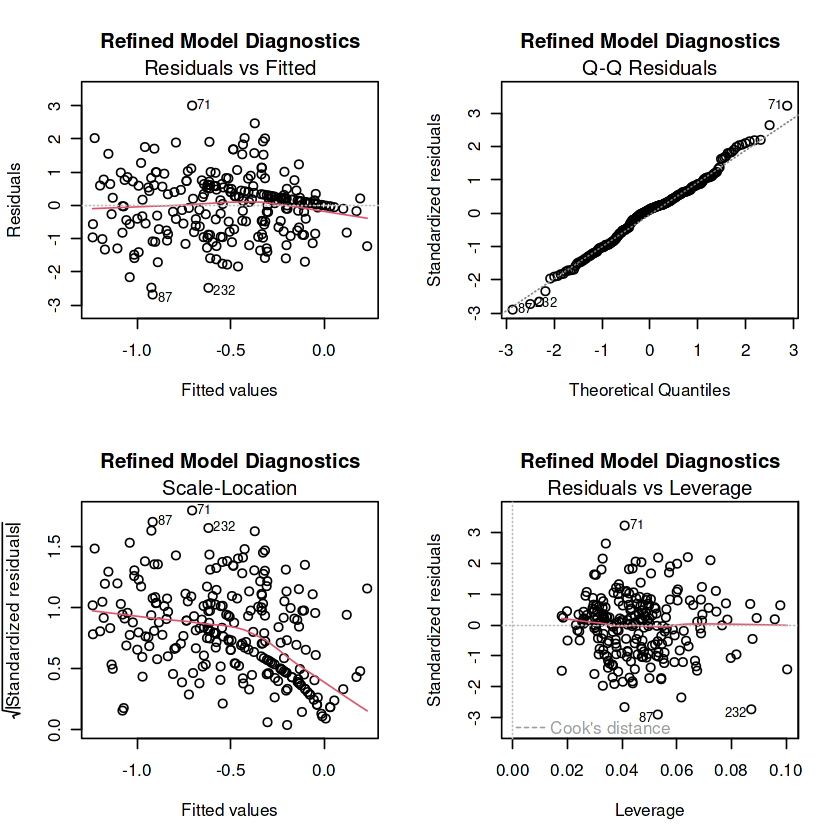

In [6]:
# Remove Age and BMI due to high VIF (>10)
model_refined <- lm(MoCA_Change_12m ~ Sex + EducationYears +
                      CognitiveScore_MoCA + PhysicalActivity_METS_week +
                      SleepQuality_PSQI + SystolicBP_mmHg +
                      HbA1c_mmol_mol + APOE4_Carrier + Diagnosis,
                    data = df)

cat("=== Refined Model Summary (Age & BMI removed) ===\n")
print(summary(model_refined))

cat("\n=== VIF — Refined Model ===\n")
print(vif(model_refined))

# Compare full vs refined model
cat("\n=== Model Comparison ===\n")
cat(sprintf("Full model:     R² = %.3f, Adj R² = %.3f, F = %.3f, p = %.5f\n",
            summary(model)$r.squared,
            summary(model)$adj.r.squared,
            summary(model)$fstatistic[1],
            pf(summary(model)$fstatistic[1],
               summary(model)$fstatistic[2],
               summary(model)$fstatistic[3],
               lower.tail = FALSE)))

cat(sprintf("Refined model:  R² = %.3f, Adj R² = %.3f, F = %.3f, p = %.5f\n",
            summary(model_refined)$r.squared,
            summary(model_refined)$adj.r.squared,
            summary(model_refined)$fstatistic[1],
            pf(summary(model_refined)$fstatistic[1],
               summary(model_refined)$fstatistic[2],
               summary(model_refined)$fstatistic[3],
               lower.tail = FALSE)))

# Residual diagnostic plots
par(mfrow = c(2, 2))
plot(model_refined, main = "Refined Model Diagnostics")
par(mfrow = c(1, 1))

=== APOE4 Interaction Model ===

Call:
lm(formula = MoCA_Change_12m ~ PhysicalActivity_METS_week * APOE4_Carrier + 
    Sex + EducationYears + CognitiveScore_MoCA + SleepQuality_PSQI + 
    SystolicBP_mmHg + HbA1c_mmol_mol + Diagnosis, data = df)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.78157 -0.63049  0.09171  0.56694  2.97872 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                               -2.276e+00  1.865e+00  -1.220
PhysicalActivity_METS_week                 2.274e-04  9.745e-05   2.333
APOE4_Carrier1                             2.177e-01  2.641e-01   0.824
SexMale                                   -1.027e-01  1.258e-01  -0.817
EducationYears                             2.287e-02  2.502e-02   0.914
CognitiveScore_MoCA                        4.299e-02  5.055e-02   0.850
SleepQuality_PSQI                         -1.560e-02  3.929e-02  -0.397
SystolicBP_mmHg                           -8.835e-04  7.59

`geom_smooth()` using formula = 'y ~ x'



=== MoCA Change by APOE4 Status ===
    APOE4_label MoCA_Change_12m.mean MoCA_Change_12m.sd MoCA_Change_12m.n
1 APOE4 Carrier               -0.601              1.120           108.000
2   Non-Carrier               -0.434              0.870           132.000


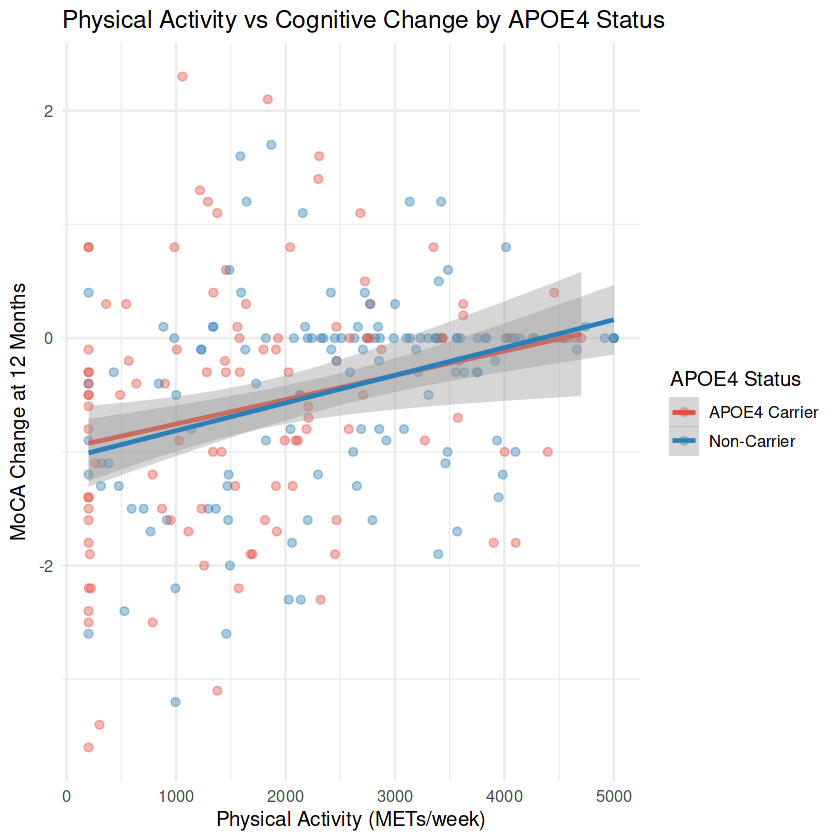

In [7]:
# Test whether APOE4 status moderates the effect of physical activity
model_interaction <- lm(MoCA_Change_12m ~ PhysicalActivity_METS_week *
                          APOE4_Carrier + Sex + EducationYears +
                          CognitiveScore_MoCA + SleepQuality_PSQI +
                          SystolicBP_mmHg + HbA1c_mmol_mol + Diagnosis,
                        data = df)

cat("=== APOE4 Interaction Model ===\n")
print(summary(model_interaction))

# Interaction plot
df$APOE4_label <- ifelse(df$APOE4_Carrier == 1, "APOE4 Carrier", "Non-Carrier")

ggplot(df, aes(x = PhysicalActivity_METS_week,
               y = MoCA_Change_12m,
               colour = APOE4_label)) +
  geom_point(alpha = 0.4, size = 1.8) +
  geom_smooth(method = "lm", se = TRUE) +
  scale_colour_manual(values = c("APOE4 Carrier" = "#e74c3c",
                                 "Non-Carrier"   = "#2980b9")) +
  labs(title = "Physical Activity vs Cognitive Change by APOE4 Status",
       x      = "Physical Activity (METs/week)",
       y      = "MoCA Change at 12 Months",
       colour = "APOE4 Status") +
  theme_minimal(base_size = 12)

# APOE4 group means
cat("\n=== MoCA Change by APOE4 Status ===\n")
apoe4_summary <- aggregate(MoCA_Change_12m ~ APOE4_label,
                            data = df, FUN = function(x)
                            c(mean = round(mean(x), 3),
                              sd   = round(sd(x), 3),
                              n    = length(x)))
print(apoe4_summary)

## 5. Key Findings & Conclusions

### Overview
This analysis examines modifiable lifestyle factors as predictors of cognitive decline in a sample
of **240 participants** across three diagnostic groups: cognitively normal (CN, n=101), mild
cognitive impairment (MCI, n=76), and Alzheimer's disease (AD, n=63). The outcome variable is
**MoCA score change over 12 months**, with five lifestyle predictors examined: physical activity,
sleep quality, BMI, systolic blood pressure, and HbA1c. Data were sourced from two linked
datasets covering biomarkers, imaging, and genetic variables collected at Swansea University
as part of the PMIM202 Health Data Modelling module.

---

### Finding 1 — All five lifestyle factors correlate with cognitive change in unadjusted analyses
Pearson correlations showed that all five lifestyle predictors were significantly associated
with MoCA change at 12 months (all p < 0.01). Physical activity had the strongest positive
association (r = 0.303, 95% CI [0.183, 0.413]), while BMI showed the strongest negative
association (r = -0.302, 95% CI [-0.413, -0.182]). Sleep quality (r = -0.178), systolic
blood pressure (r = -0.175), and HbA1c (r = -0.168) all showed modest but significant
negative associations with cognitive change.

---

### Finding 2 — Diagnosis is the dominant predictor of cognitive decline
One-way ANOVA showed a significant effect of diagnostic group on MoCA change
(F(2,237) = 8.23, p < 0.001). Tukey post-hoc tests confirmed that AD patients declined
significantly more than both CN (p = 0.0004) and MCI participants (p = 0.004), while
MCI and CN groups did not differ significantly from each other (p = 0.873). This pattern
held across all regression models, with diagnosis consistently the strongest predictor
of 12-month cognitive change.

---

### Finding 3 — Physical activity remains significant after adjusting for confounders
In the full regression model (R² = 0.120, F(12,227) = 2.579, p = 0.003), no lifestyle
predictor reached significance after adjustment — consistent with diagnosis absorbing
much of the variance. However, a multicollinearity check revealed severe VIF inflation
for Age (VIF = 229) and BMI (VIF = 262), indicating these variables were collinear with
Diagnosis. After removing them, the refined model (R² = 0.116, F(10,229) = 3.007,
p = 0.001) showed improved model stability and physical activity emerged as the only
significant lifestyle predictor (β = 0.000194, p = 0.034). Each additional 1,000 METs
per week of physical activity was associated with approximately 0.19 points less
cognitive decline over 12 months.

---

### Finding 4 — APOE4 status does not moderate the effect of physical activity
APOE4 carriers showed worse average MoCA change (-0.601) compared to non-carriers
(-0.434), consistent with the known genetic risk conferred by the APOE4 allele.
However, the interaction between physical activity and APOE4 status was non-significant
(p = 0.349), indicating that the protective effect of physical activity on cognitive
outcomes does not differ by genetic risk group. This suggests physical activity may
be beneficial regardless of APOE4 carrier status.

---

### Finding 5 — Lifestyle factors explain modest but meaningful variance
Across all models, the lifestyle and demographic predictors together explained
approximately 12% of variance in 12-month cognitive change (R² ≈ 0.12). While
modest, this is consistent with the broader literature on lifestyle interventions
in cognitive ageing, where effect sizes are typically small and diagnosis stage
dominates short-term cognitive trajectories. The adjusted R² of 0.077 in the
refined model reflects the genuine but limited predictive value of modifiable
lifestyle factors over a 12-month window in a clinically heterogeneous sample.

---

### Conclusion
Physical activity, sleep quality, BMI, blood pressure, and HbA1c are all significantly
associated with 12-month cognitive change in unadjusted analyses. After controlling
for diagnosis, demographics, and genetic risk, physical activity remains the only
lifestyle factor with a significant independent association with cognitive outcomes
(β = 0.000194, p = 0.034). Diagnostic group is the dominant predictor throughout,
highlighting the importance of disease stage in short-term cognitive trajectories.
These findings support targeted physical activity interventions as a modifiable
strategy for reducing cognitive decline, particularly in pre-dementia populations,
and are consistent with evidence from large-scale prevention trials such as FINGER
and MAPT.

---

*Data source: PMIM202 Health Data Modelling module datasets, Swansea University*
*Analysis by: Yousuf (Student ID: 2545745) | MSc Health Data Science, Swansea University*